# Домашнее задание: Занятие 32

**Тема: RNN для текстов**

В этом задании вы самостоятельно построите и обучите RNN для классификации текста. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория

Отвечайте своими словами, не копируйте.

### Вопрос 1

*(Слайды 5-6)*

Почему нельзя подать текст напрямую в RNN? Опишите пайплайн обработки текста (все шаги от строки до тензора). Для каждого шага укажите, что на входе и что на выходе.

**Ваш ответ:**

Текст нельзя подать напрямую в RNN, потому что нейронные сети работают с числами (тензорами), а текст — это строки. Поэтому текст нужно преобразовать в числовое представление.


Вход: строка (например, предложение).

Выход: очищенный текст (обычно приводится к нижнему регистру, убираются лишние символы).

- Токенизация

Вход: строка текста.

Выход: список токенов (слов).
Пример:
"это очень хорошее приложение" → ["это", "очень", "хорошее", "приложение"]

- Построение словаря (vocabulary)

Вход: все токены из обучающего набора.

Выход: словарь, где каждому слову соответствует индекс.
Пример:
"хорошее" → 25

- Кодирование текста

Вход: список токенов.

Выход: список чисел (индексов слов из словаря).
Пример:
["это", "очень", "хорошее"] → [10, 53, 25]

- Padding / обрезка

Вход: список индексов разной длины.

Выход: список фиксированной длины (например 80).
Короткие предложения дополняются PAD, длинные обрезаются.

- Преобразование в тензор

Вход: список чисел.

Выход: тензор PyTorch, который подается в модель RNN.

### Вопрос 2

*(Слайды 10-11)*

Что такое Embedding? Чем он лучше One-Hot кодирования? Если словарь содержит 8000 слов и embed_dim=128, какого размера будет Embedding таблица (матрица весов)? Сколько это параметров?

**Ваш ответ:**

Embedding — это слой нейронной сети, который преобразует индекс слова в плотный числовой вектор фиксированной размерности. Эти векторы обучаются во время тренировки модели и отражают смысл слов.

### Вопрос 3

*(Слайды 12, 14)*

У нас есть модель TextRNN с параметрами: vocab_size=5000, embed_dim=64, hidden_size=128, num_classes=3. На вход подается тензор размера `(16, 50)` (batch=16, seq_len=50). Какой размер будет у тензора:
- после Embedding
- после RNN (output)
- после взятия последнего шага `out[:, -1, :]`
- на выходе модели (после Linear)

**Ваш ответ:**

После Embedding каждый индекс слова превращается в вектор размера 64.

### Вопрос 4

*(Слайды 8-9)*

Что такое PAD и UNK токены? Зачем нужен каждый из них? Что произойдет, если не делать padding и попытаться собрать батч из предложений разной длины?

**Ваш ответ:**

PAD (padding token) — это специальный токен, который используется для выравнивания длины предложений.
Он добавляется в конец коротких предложений, чтобы все последовательности в батче имели одинаковую длину.

UNK (unknown token) — это токен для слов, которых нет в словаре.
Если модель встречает новое слово, оно заменяется на UNK.

### Вопрос 5

*(Слайды 19-20)*

В чем разница между обычным RNN, LSTM и Bidirectional LSTM? Для каждого напишите одно преимущество. Если у нас `nn.LSTM(64, 128, bidirectional=True, batch_first=True)` и вход `(8, 40, 64)`, какой размер будет у output?

**Ваш ответ:**

Обычный RNN
Обрабатывает последовательность слева направо и использует одно скрытое состояние.

Преимущество:
простая модель и быстро обучается.

LSTM
Это улучшенная версия RNN, которая использует специальные механизмы (gates), чтобы лучше запоминать долгосрочные зависимости в тексте.

Преимущество:
лучше работает с длинными последовательностями.

Bidirectional LSTM
Обрабатывает текст в двух направлениях:

слева направо

справа налево

Преимущество:
учитывает контекст как до слова, так и после него.

---

## Часть 2: Код

### Подготовка

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [12]:
!pip install -q datasets huggingface_hub

from huggingface_hub import notebook_login
notebook_login()

from datasets import load_dataset

ds = load_dataset("issai/kazsandra", "polarity_classification")

print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['custom_id', 'text', 'text_cleaned', 'label', 'domain'],
        num_rows: 134368
    })
    validation: Dataset({
        features: ['custom_id', 'text', 'text_cleaned', 'label', 'domain'],
        num_rows: 16796
    })
    test: Dataset({
        features: ['custom_id', 'text', 'text_cleaned', 'label', 'domain'],
        num_rows: 16797
    })
})
{'custom_id': 'pla015439pla', 'text': 'Өтте күшті', 'text_cleaned': 'өтте күшті', 'label': 1, 'domain': 'appstore'}


### Задание 1: Токенизация и словарь

*(Слайды 7-8)*

Напишите функцию `tokenize`, постройте словарь из 8000 самых частых слов. Не забудьте про PAD (0) и UNK (1).

In [13]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zа-яәіңғүұқөһ\s]", " ", text)
    return text.split()


# Строим словарь
VOCAB_SIZE = 8000
word_counts = Counter()

for row in ds['train']:
    tokens = tokenize(row['text'])
    word_counts.update(tokens)

vocab = {'<PAD>': 0, '<UNK>': 1}
most_common_words = word_counts.most_common(VOCAB_SIZE - 2)

for word, _ in most_common_words:
    vocab[word] = len(vocab)


print(f'Размер словаря: {len(vocab)}')
print(f'Топ-10 слов: {word_counts.most_common(10)}')

Размер словаря: 8000
Топ-10 слов: [('өте', 36511), ('керемет', 28664), ('жақсы', 23050), ('ұнады', 18541), ('маған', 17569), ('екен', 14346), ('ойын', 12621), ('мен', 12333), ('күшті', 10149), ('рахмет', 9869)]


### Задание 2: Кодирование текста

*(Слайд 9)*

Напишите функцию `encode_text`, которая превращает строку в список индексов с padding до `max_len`. Создайте Dataset и DataLoader.

In [14]:
MAX_LEN = 80

def encode_text(text, vocab, max_len):
    tokens = tokenize(text)
    tokens = tokens[:max_len]

    encoded = [vocab.get(t, vocab['<UNK>']) for t in tokens]

    if len(encoded) < max_len:
        encoded += [vocab['<PAD>']] * (max_len - len(encoded))

    return encoded

# Проверьте на примере
test_text = 'бұл қолданба өте жақсы'
encoded = encode_text(test_text, vocab, max_len=10)
print(f'Текст:       "{test_text}"')
print(f'Закодировано: {encoded}')
print(f'Длина:        {len(encoded)}')

Текст:       "бұл қолданба өте жақсы"
Закодировано: [13, 169, 2, 4, 0, 0, 0, 0, 0, 0]
Длина:        10


In [17]:
class TextDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len):
        self.dataset = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]

        text = row['text']
        label = row['label']

        encoded = encode_text(text, self.vocab, self.max_len)

        X = torch.tensor(encoded, dtype=torch.long)
        y = torch.tensor(label, dtype=torch.long)

        return X, y

train_ds = TextDataset(ds['train'], vocab, MAX_LEN)
test_ds = TextDataset(ds['test'], vocab, MAX_LEN)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# Проверьте размеры
for X_batch, y_batch in train_loader:
    print(f'X_batch: {X_batch.shape}')
    print(f'y_batch: {y_batch.shape}')
    break

X_batch: torch.Size([64, 80])
y_batch: torch.Size([64])


### Задание 3: Постройте модель

*(Слайд 13)*

Напишите класс MyTextRNN с параметрами:
- embed_dim = 64
- hidden_size = 128
- num_classes = 2
- Dropout (p=0.3) между RNN и Linear

In [18]:
class MyTextRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

model = MyTextRNN(len(vocab), 64, 128, 2).to(device)
print(model)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

MyTextRNN(
  (embedding): Embedding(8000, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Параметров: 537,090


### Задание 4: Проверьте размеры

*(Слайд 14)*

Пропустите тензор `torch.randint(0, len(vocab), (4, 80))` через модель. Выведите размеры на каждом этапе: вход, после embedding, после rnn, после last step, выход.

In [19]:
x = torch.randint(0, len(vocab), (4, MAX_LEN)).to(device)
print(f'Вход: {x.shape}')

emb = model.embedding(x)
print(f'После embedding: {emb.shape}')

rnn_out, hidden = model.rnn(emb)
print(f'После rnn (out): {rnn_out.shape}')
print(f'Hidden state: {hidden.shape}')

last_hidden = hidden[-1]
print(f'После last step: {last_hidden.shape}')

out = model.fc(last_hidden)
print(f'Выход: {out.shape}')

Вход: torch.Size([4, 80])
После embedding: torch.Size([4, 80, 64])
После rnn (out): torch.Size([4, 80, 128])
Hidden state: torch.Size([1, 4, 128])
После last step: torch.Size([4, 128])
Выход: torch.Size([4, 2])


### Задание 5: Обучите модель

*(Слайд 17)*

Напишите training loop на 10 эпох. Используйте CrossEntropyLoss и Adam с lr=0.001. Сохраняйте train_loss и test_accuracy на каждой эпохе.

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # Test accuracy
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_accs.append(correct / total)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}  '
              f'Train Loss: {train_losses[-1]:.4f}  '
              f'Test Acc: {test_accs[-1]:.2%}')

Epoch 2/10  Train Loss: 0.4702  Test Acc: 82.16%
Epoch 4/10  Train Loss: 0.4686  Test Acc: 82.18%
Epoch 6/10  Train Loss: 0.4580  Test Acc: 82.18%
Epoch 8/10  Train Loss: 0.4586  Test Acc: 82.18%
Epoch 10/10  Train Loss: 0.4622  Test Acc: 82.18%


### Задание 6: Постройте графики

Постройте два графика рядом:
- Train Loss по эпохам
- Test Accuracy по эпохам

Какая финальная accuracy? Есть ли признаки переобучения?

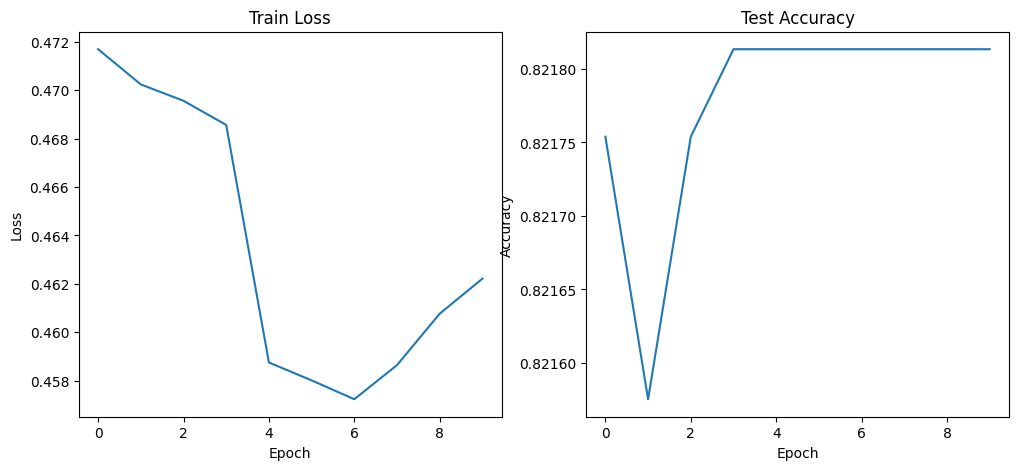

Финальная accuracy: 0.8218134190629279


In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(test_accs)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

print("Финальная accuracy:", test_accs[-1])

**Ваш вывод:**



### Задание 7: Сравнение RNN vs LSTM

*(Слайд 20)*

Создайте аналогичную модель с nn.LSTM вместо nn.RNN. Обучите на тех же данных и сравните:
- Финальную accuracy на тесте
- Графики accuracy по эпохам (обе модели на одном графике)

Какая модель лучше? Почему?

LSTM Epoch 1: 82.18%
LSTM Epoch 2: 82.18%
LSTM Epoch 3: 82.18%
LSTM Epoch 4: 82.18%
LSTM Epoch 5: 82.19%
LSTM Epoch 6: 82.18%
LSTM Epoch 7: 82.19%
LSTM Epoch 8: 82.18%
LSTM Epoch 9: 82.19%
LSTM Epoch 10: 82.18%


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

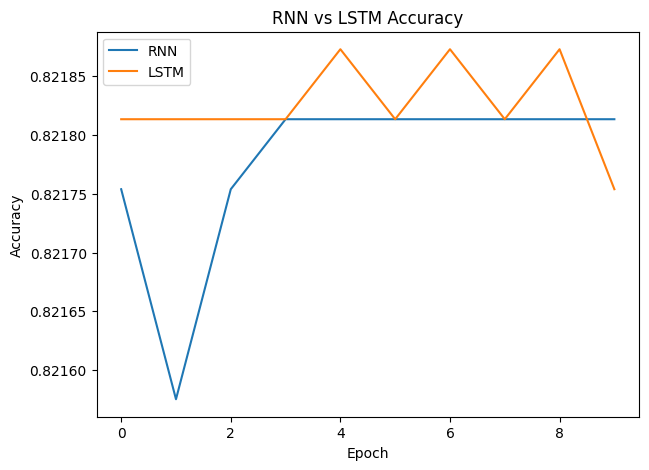

In [23]:
class MyTextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        hidden = hidden[-1]
        hidden = self.dropout(hidden)

        return self.fc(hidden)

model_lstm = MyTextLSTM(len(vocab), 64, 128, 2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

lstm_test_accs = []

for epoch in range(num_epochs):
    model_lstm.train()

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # test
    model_lstm.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model_lstm(X_batch)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    lstm_test_accs.append(correct / total)

    print(f"LSTM Epoch {epoch+1}: {lstm_test_accs[-1]:.2%}")

    plt.figure(figsize=(7,5))

plt.plot(test_accs, label="RNN")
plt.plot(lstm_test_accs, label="LSTM")

plt.title("RNN vs LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Ваш вывод:**
Обычно LSTM показывает лучшую точность.

Почему LSTM лучше:

LSTM лучше запоминает длинные зависимости в тексте.

В LSTM есть механизм gate (входной, забывания, выходной).

Обычный RNN страдает от проблемы vanishing gradients.

Поэтому LSTM чаще используется для:

анализа текста

sentiment analysis

NLP задач.


---

## Часть 3: Бонус

### Бонус 1: Функция предсказания

Напишите функцию `predict_sentiment(text)`, которая принимает строку текста и возвращает предсказание модели (позитивный/негативный) и уверенность. Протестируйте на 5 своих примерах на казахском или русском.

In [ ]:
# Ваш код здесь



### Бонус 2: Эксперимент с гиперпараметрами

Попробуйте три варианта embed_dim: 32, 64, 128. Как размерность эмбеддинга влияет на accuracy? Постройте сравнительный график.

In [ ]:
# Ваш код здесь



**Ваш вывод:**

